In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

In [7]:
virulence_matches = pd.read_csv("../data/kpneumo/summary_virulence.txt", sep="\t")
vir_kleb = pd.read_csv("../data/kpneumo/report_kleborate", sep="\t")

In [8]:
def transform_df(df):
    """
    Transforms an AMR category DataFrame into a binary matrix (0/1) indicating the presence of resistance genes.
    Adds an "MDR" column with 1 if three or more antibiotic classes (excluding "Efflux" and "ESBL (AmpC type)") have resistance.
    
    Parameters:
    df (pd.DataFrame): DataFrame with AMR categories as columns and resistance genes as values.
    
    Returns:
    pd.DataFrame: Transformed DataFrame with 0s and 1s, including an "MDR" column.
    """
    # Convert all values to string to handle NaN values correctly
    df_binary = df.iloc[:, 1:].notna().astype(int)
    
    # Add back the first two columns (sample identifiers)
    df_binary.insert(0, df.columns[0], df.iloc[:, 0])

    return df_binary

In [9]:
vir = transform_df(virulence_matches)

In [10]:
def plot_amr_category_frequency(df_binary):
    """
    Plots the frequency of resistance presence by AMR category as a bar plot with a secondary axis.
    The "MDR" bar is highlighted with alpha = 0.5.
    
    Parameters:
    df_binary (pd.DataFrame): Binary AMR DataFrame with 0s and 1s.
    """
    # Summing across rows to get frequency per category
    amr_frequencies = df_binary.iloc[:, 1:].sum().sort_values(ascending=False)

    # Plot setup
    fig, ax1 = plt.subplots(figsize=(12, 9))
    
    # Primary axis - Frequency
    bars = ax1.bar(amr_frequencies.index, amr_frequencies.values, color='xkcd:salmon', label='Frequency', alpha=0.6)
    ax1.set_xlabel("VF Category")
    ax1.set_ylabel("Frequency")
    ax1.set_xticklabels(amr_frequencies.index, rotation=45, ha="right")
    
    plt.title("K. pneumoniae")
    plt.tight_layout()
    plt.savefig("../out/vir_kpneumoniae.svg", format="svg", dpi=150)
    plt.savefig("../out/vir_kpneumoniae.png", format="png", dpi=150)

    plt.show();

/tmp/ipykernel_18371/1976612229.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(amr_frequencies.index, rotation=45, ha="right")


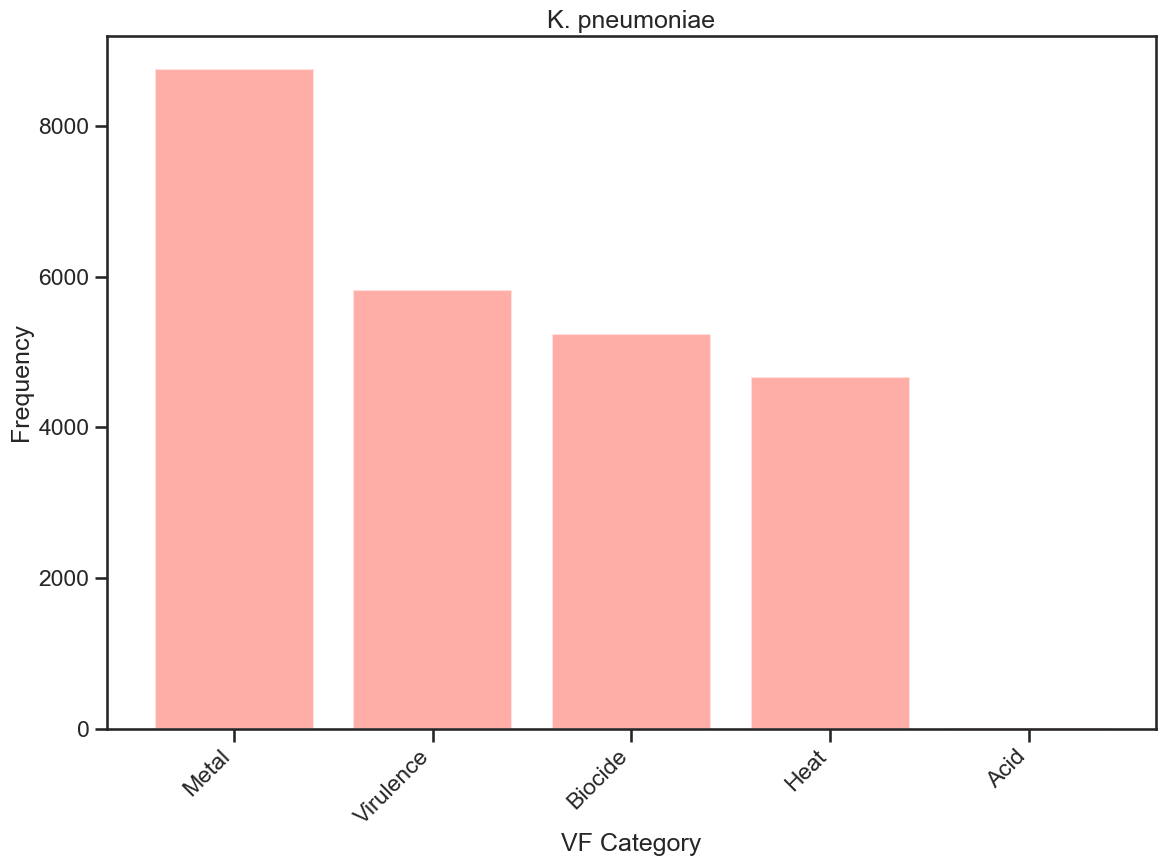

In [11]:
plot_amr_category_frequency(vir)

In [13]:
virulence_matches

,Isolate,Virulence,Biocide,Heat,Metal,Acid
0,1085_F1S1R3D1B1P5A04,"ybtP,ybtQ",qacEdelta1,hsp20,"arsA,arsB,arsD,arsR,pcoA,pcoB,pcoC,pcoD,pcoE,p...",NaN
1,1085_F1S1R3D1B1P5A11,"iucA,iucB,iucC,iutA",qacEdelta1,NaN,"terB,terC,terD,terE",NaN
2,1085_F1S1R3D1B1P5B03,"iroB,iroC,iroD,iroN,iucA,iucB,iucC,iutA,rmpA,r...",crcB,NaN,"pcoA,pcoB,pcoC,pcoD,pcoR,pcoS,silA,silB,silC,s...",NaN
3,1085_F1S1R3D1B1P5B08,"iucA,iucB,iucC,iutA,rmpA,rmpD",qacEdelta1,NaN,"arsA,arsB,arsD,arsR,pcoA,pcoB,pcoC,pcoD,pcoE,p...",NaN
4,1085_F1S1R3D1B1P5B11,"iucA,iucB,iucC,iutA",qacEdelta1,NaN,"terB,terC,terD,terE",NaN
...,...,...,...,...,...,...
11195,SRR9858977,NaN,qacE,hsp20,"arsA,arsB,arsD,arsR,merC,pcoA,pcoB,pcoC,pcoD,p...",NaN
11196,SRR9858978,NaN,qacE,hsp20,"arsA,arsB,arsD,arsR,pcoA,pcoB,pcoC,pcoD,pcoE,p...",NaN
11197,SRR9858979,"ybtP,ybtQ",qacEdelta1,NaN,"merA,merC,merD,merE,merP,merR,merT",NaN
11198,SRR9858980,NaN,qacEdelta1,hsp20,"arsA,arsB,arsD,arsR,ncrA,ncrB,ncrC,ncrY,pcoA,p...",NaN


In [15]:
kleb_score = pd.read_csv("../../PIBET/data/kpneumo/kpneumoniae_data_2023.tsv", sep="\t")

In [17]:
kleb_score = kleb_score[["sampleid", "virulence_score"]]

In [19]:
score_binary = kleb_score['virulence_score'].astype(pd.CategoricalDtype(categories=[0, 1, 2, 3, 4, 5]))
score_binary = pd.get_dummies(score_binary, prefix="score")
score_binary.index = kleb_score.sampleid

In [23]:
def plot_virulencescore_frequency(df_binary):
    """
    Plots the frequency of virulence factor presence by category as a bar plot.

    Parameters:
    df_binary (pd.DataFrame): Binary VF DataFrame with 0s and 1s (Isolates x Categories).
    """
    ordered_cols = [f"score_{i}" for i in range(6) if f"score_{i}" in df_binary.columns]
    vir_frequencies = df_binary[ordered_cols].sum()

    if len(df_binary) <= 10:
        print(f"Not enough isolates to plot: {len(df_binary)} (≤10). Skipping plot.")
        return

    if (vir_frequencies < 10).all():
        print("No virulence scores with frequency ≥10. Skipping plot.")
        return

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(
        x=vir_frequencies.index,
        y=vir_frequencies.values,
        order=ordered_cols,
        color='xkcd:salmon',
        alpha=0.6,
        ax=ax
    )

    ax.set_xlabel("Virulence Score")
    ax.set_ylabel("Frequency")
    ax.set_title("K. pneumoniae")
    ax.set_facecolor("white")
    ax.tick_params(axis='x', rotation=45)

    sns.despine()
    plt.tight_layout()
    plt.savefig("../out/vir_score_kpneumoniae.svg", format="svg", dpi=150)
    plt.savefig("../out/vir_score_kpneumoniae.png", format="png", dpi=150)
    plt.show()

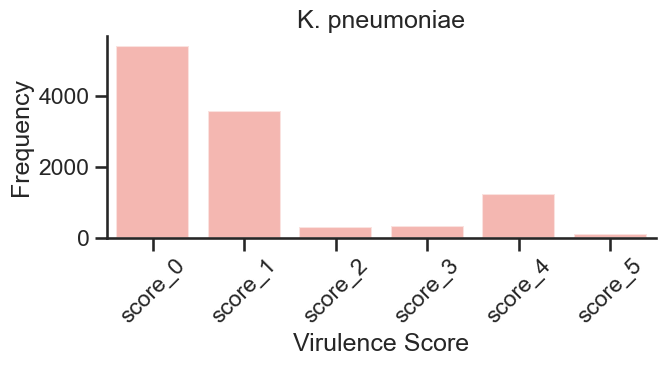

In [24]:
plot_virulencescore_frequency(score_binary)